# Load data

In [1]:
import pandas as pd

In [2]:
train_df = pd.read_csv('../data/processed/train.csv')
val_df = pd.read_csv('../data/processed/val.csv')
test_df = pd.read_csv('../data/processed/test.csv')
train_df.shape, val_df.shape, test_df.shape

((172064, 65), (43016, 65), (53770, 65))

In association rule mining, we do not need to split the dataset, so we concatenate all subsets into a single dataset and analyze their patterns.

In [3]:
import pandas as pd

df = pd.concat([train_df, val_df, test_df], axis=0, ignore_index=True)
df.shape

(268850, 65)

In [4]:
drop_cols = ['serviceCharge', 'picturecount', 'yearConstructed', 'pricetrend', 'baseRent', 'regio2_freq', 'numberOfFloors', 'floor']
df.drop(columns=drop_cols, inplace=True)

In [5]:
df['rent_level'] = pd.qcut(df['totalRent'], q=3, labels=['low','medium','high'])
df['space_level'] = pd.qcut(df['livingSpace'], q=3, labels=['small','medium','large'])
df['room_level'] = pd.qcut(df['noRooms'], q=3, labels=['few','medium','many'])
# One-hot encode
df = pd.get_dummies(df, columns=['rent_level','space_level','room_level'])

df.drop(columns=['totalRent', 'livingSpace', 'noRooms'], inplace=True)


In [6]:
df = df.astype('bool')
df.dtypes

newlyConst            bool
balcony               bool
hasKitchen            bool
cellar                bool
lift                  bool
                      ... 
space_level_medium    bool
space_level_large     bool
room_level_few        bool
room_level_medium     bool
room_level_many       bool
Length: 63, dtype: object

In [7]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(df, 
                           min_support=0.05,   
                           use_colnames=True)

frequent_itemsets = frequent_itemsets.sort_values(by='support', ascending=False)
frequent_itemsets

,support,itemsets
3,0.640636,(cellar)
1,0.616455,(balcony)
33,0.447298,(room_level_few)
39,0.435555,"(balcony, cellar)"
34,0.408555,(room_level_medium)
...,...,...
368,0.050351,"(balcony, rent_level_medium, lift, cellar)"
234,0.050288,"(balcony, rent_level_medium, condition_unknown)"
349,0.050218,"(room_level_few, space_level_small, typeOfFlat..."
68,0.050199,"(hasKitchen, regio1_nordrhein_westfalen)"


In [8]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_itemsets, 
                          metric="confidence", 
                          min_threshold=0.6)

rules = rules[
    (rules['lift'] > 2) &
    (rules['confidence'] > 0.7) &
    (rules['support'] > 0.05)
]

rules = rules.sort_values(by='lift', ascending=False)
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
171,"(space_level_small, regio1_sachsen)","(room_level_few, rent_level_low)",0.094298,0.225933,0.072405,0.767829,3.398486,1.0,0.051100,3.334039,0.779231,0.292159,0.700064,0.544150
346,"(balcony, newlyConst)",(lift),0.068034,0.235529,0.050147,0.737084,3.129481,1.0,0.034123,2.907660,0.730132,0.197883,0.656081,0.474998
279,(newlyConst),(lift),0.078747,0.235529,0.055563,0.705588,2.995756,1.0,0.037015,2.596601,0.723139,0.214765,0.614881,0.470747
329,"(balcony, rent_level_high, room_level_many)",(space_level_large),0.058267,0.333323,0.051627,0.886052,2.658234,1.0,0.032206,5.850694,0.662407,0.151862,0.829080,0.520469
202,"(rent_level_high, room_level_many)",(space_level_large),0.074302,0.333323,0.065817,0.885813,2.657518,1.0,0.041051,5.838462,0.673771,0.192557,0.828722,0.541635
311,"(hasKitchen, room_level_few, rent_level_low)",(space_level_small),0.061350,0.333465,0.052933,0.862799,2.587376,1.0,0.032475,4.858079,0.653607,0.154828,0.794157,0.510767
303,"(room_level_few, condition_unknown, rent_level...",(space_level_small),0.063028,0.333465,0.053327,0.846090,2.537271,1.0,0.032310,4.330690,0.646631,0.155398,0.769090,0.503004
300,"(space_level_small, cellar, regio1_sachsen)",(rent_level_low),0.062752,0.336939,0.053450,0.851757,2.527929,1.0,0.032306,4.472813,0.644888,0.154372,0.776427,0.505196
168,"(room_level_few, space_level_small, regio1_sac...",(rent_level_low),0.085557,0.336939,0.072405,0.846274,2.511656,1.0,0.043577,4.313273,0.658167,0.206817,0.768158,0.530582
139,"(space_level_small, regio1_sachsen)",(rent_level_low),0.094298,0.336939,0.079401,0.842024,2.499042,1.0,0.047629,4.197235,0.662300,0.225677,0.761748,0.538839


In [9]:
def filter_minimal_rules(rules):
    rules = rules.copy()
    
    # độ dài antecedent
    rules['ante_len'] = rules['antecedents'].apply(len)
    
    # 🔥 sort chuẩn: ưu tiên rule tốt + ngắn
    rules = rules.sort_values(
        by=['consequents', 'lift', 'confidence', 'ante_len'],
        ascending=[True, False, False, True]
    )
    
    selected = []
    
    for _, rule in rules.iterrows():
        keep = True
        
        for sel in selected:
            if rule['consequents'] == sel['consequents']:
                
                # chỉ bỏ nếu thực sự bị "bao" bởi rule tốt hơn
                if (rule['antecedents'].issuperset(sel['antecedents']) and
                    sel['lift'] >= rule['lift']):
                    keep = False
                    break
        
        if keep:
            selected.append(rule)
    
    return pd.DataFrame(selected).drop(columns=['ante_len'])

In [10]:
clean_rules = filter_minimal_rules(rules)
clean_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
171,"(space_level_small, regio1_sachsen)","(room_level_few, rent_level_low)",0.094298,0.225933,0.072405,0.767829,3.398486,1.0,0.051100,3.334039,0.779231,0.292159,0.700064,0.544150
346,"(balcony, newlyConst)",(lift),0.068034,0.235529,0.050147,0.737084,3.129481,1.0,0.034123,2.907660,0.730132,0.197883,0.656081,0.474998
279,(newlyConst),(lift),0.078747,0.235529,0.055563,0.705588,2.995756,1.0,0.037015,2.596601,0.723139,0.214765,0.614881,0.470747
329,"(balcony, rent_level_high, room_level_many)",(space_level_large),0.058267,0.333323,0.051627,0.886052,2.658234,1.0,0.032206,5.850694,0.662407,0.151862,0.829080,0.520469
202,"(rent_level_high, room_level_many)",(space_level_large),0.074302,0.333323,0.065817,0.885813,2.657518,1.0,0.041051,5.838462,0.673771,0.192557,0.828722,0.541635
101,"(balcony, rent_level_high, room_level_medium)",(space_level_large),0.123686,0.333323,0.092739,0.749797,2.249458,1.0,0.051512,2.664543,0.633846,0.254590,0.624701,0.514012
130,"(balcony, room_level_many)",(space_level_large),0.108064,0.333323,0.080275,0.742849,2.228614,1.0,0.044255,2.592552,0.618083,0.222300,0.614280,0.491841
84,(room_level_many),(space_level_large),0.144147,0.333323,0.106238,0.737008,2.211089,1.0,0.058190,2.534967,0.639987,0.286175,0.605518,0.527865
138,"(rent_level_high, cellar, room_level_medium)",(space_level_large),0.107863,0.333323,0.079464,0.736715,2.210211,1.0,0.043511,2.532149,0.613756,0.219683,0.605078,0.487558
67,"(rent_level_high, room_level_medium)",(space_level_large),0.158735,0.333323,0.116764,0.735589,2.206833,1.0,0.063854,2.521366,0.650047,0.311126,0.603390,0.542946


## 🔍 Top Association Rules and Their Interpretations

The following rules represent the most significant patterns discovered from the dataset, based on high values of support, confidence, and lift. These rules reveal meaningful relationships between apartment characteristics such as size, location, amenities, and pricing.

---

### 1. (space_level_small, regio1_sachsen) → (room_level_few, rent_level_low)

This rule indicates that apartments located in Sachsen with small space are very likely to have fewer rooms and lower rent. This reflects a strong relationship between **location and housing affordability**, suggesting that smaller apartments in this region tend to be budget-friendly and compact.

---

### 2. (newlyConst) → (lift)

This rule shows that newly constructed apartments are highly likely to have an elevator. This is consistent with modern housing standards, where newer buildings are typically equipped with better infrastructure and accessibility features.

---

### 3. (rent_level_high, room_level_many) → (space_level_large)

This rule confirms that apartments with higher rent and more rooms are strongly associated with larger space. This is an expected but important pattern, reinforcing the relationship between **price, size, and capacity**.

---

### 4. (room_level_few, rent_level_low, hasKitchen) → (space_level_small)

This rule suggests that apartments with fewer rooms and lower rent, even when equipped with a kitchen, are still likely to have small space. It highlights that the presence of basic amenities like a kitchen does not necessarily imply larger apartment size.

---

### 5. (cellar, space_level_small, regio1_sachsen) → (rent_level_low)

This rule indicates that small apartments in Sachsen with a cellar are still likely to have low rent. The presence of a cellar does not significantly increase the rental price, suggesting that **location and size remain the dominant factors** influencing rent.

---

### 6. (lift, space_level_small) → (room_level_few)

This rule shows that even if a small apartment has an elevator, it is still likely to have fewer rooms. This implies that while certain amenities improve convenience, they do not necessarily correlate with larger living space or room count.

---

## 📊 Summary

Overall, these rules highlight several key insights:

- **Apartment size, rent, and number of rooms are strongly correlated**
- **Location plays an important role in determining rental price**
- **Modern features (e.g., lift) are associated with newer buildings**
- **Some amenities (e.g., cellar, kitchen) have limited impact on core property characteristics**

These findings provide a deeper understanding of the relationships within the housing dataset and can be useful for both real estate analysis and decision-making.

In [11]:
def analyze_feature_importance(rule, rules_df):
    antecedents = set(rule['antecedents'])
    consequent = rule['consequents']
    
    base_conf = rule['confidence']
    
    results = []
    
    for item in antecedents:
        reduced = antecedents - {item}
        
        # tìm rule tương ứng
        match = rules_df[
            (rules_df['antecedents'] == reduced) &
            (rules_df['consequents'] == consequent)
        ]
        
        if not match.empty:
            new_conf = match.iloc[0]['confidence']
            impact = base_conf - new_conf
        else:
            new_conf = None
            impact = None
        
        results.append({
            'removed_item': item,
            'new_confidence': new_conf,
            'impact': impact
        })
    
    return pd.DataFrame(results)


In [12]:
top_rules = rules.loc[[171, 279, 202, 311, 301, 218]]  

KeyError: '[301] not in index'

In [ ]:
for idx, rule in top_rules.iterrows():
    print(f"Analyzing Rule {idx}: {rule['antecedents']} => {rule['consequents']}")
    importance_df = analyze_feature_importance(rule, rules)
    print(importance_df)
    print("\n")

Analyzing Rule 171: frozenset({'regio1_sachsen', 'space_level_small'}) => frozenset({'room_level_few', 'rent_level_low'})
        removed_item new_confidence impact
0     regio1_sachsen           None   None
1  space_level_small           None   None


Analyzing Rule 279: frozenset({'newlyConst'}) => frozenset({'lift'})
  removed_item new_confidence impact
0   newlyConst           None   None


Analyzing Rule 202: frozenset({'rent_level_high', 'room_level_many'}) => frozenset({'space_level_large'})
      removed_item  new_confidence    impact
0  rent_level_high        0.737008  0.148805
1  room_level_many             NaN       NaN


Analyzing Rule 311: frozenset({'room_level_few', 'rent_level_low', 'hasKitchen'}) => frozenset({'space_level_small'})
     removed_item  new_confidence    impact
0  room_level_few        0.759213  0.103586
1  rent_level_low             NaN       NaN
2      hasKitchen        0.823302  0.039497


Analyzing Rule 301: frozenset({'regio1_sachsen', 'cellar', 'spa

### Rule Explanation

1. `(space_level_small, regio1_sachsen) → (room_level_few, rent_level_low)`: The rule relies on the combination of both location and size, indicating that neither factor alone is sufficient to explain the outcome.
2. `(newlyConst) → (lift)`: As this rule contains only one antecedent, feature importance analysis is not applicable.
3. `(rent_level_high, room_level_many) → (space_level_large)`: The rent level appears to be a key driver of the rule, as removing it significantly reduces confidence.
4. `(room_level_few, rent_level_low, hasKitchen) → (space_level_small)`: The number of rooms has the strongest influence, while the presence of a kitchen contributes less significantly.
5. `(cellar, space_level_small, regio1_sachsen) → (rent_level_low)`: The presence of a cellar has minimal impact on the rule, suggesting it is not a key factor.
6. `(lift, space_level_small) → (room_level_few)`: The rule depends on the joint effect of both features, indicating a combined relationship.

# Visualization

In [ ]:
import matplotlib.pyplot as plt

top_rules_sorted = top_rules.sort_values(by='lift', ascending=True)

labels = [
    f"{set(a)} → {set(c)}"
    for a, c in zip(top_rules_sorted['antecedents'], top_rules_sorted['consequents'])
]

plt.figure(figsize=(8,6))
plt.barh(labels, top_rules_sorted['lift'])

plt.xlabel('Lift')
plt.title('Top Association Rules by Lift')

plt.show()

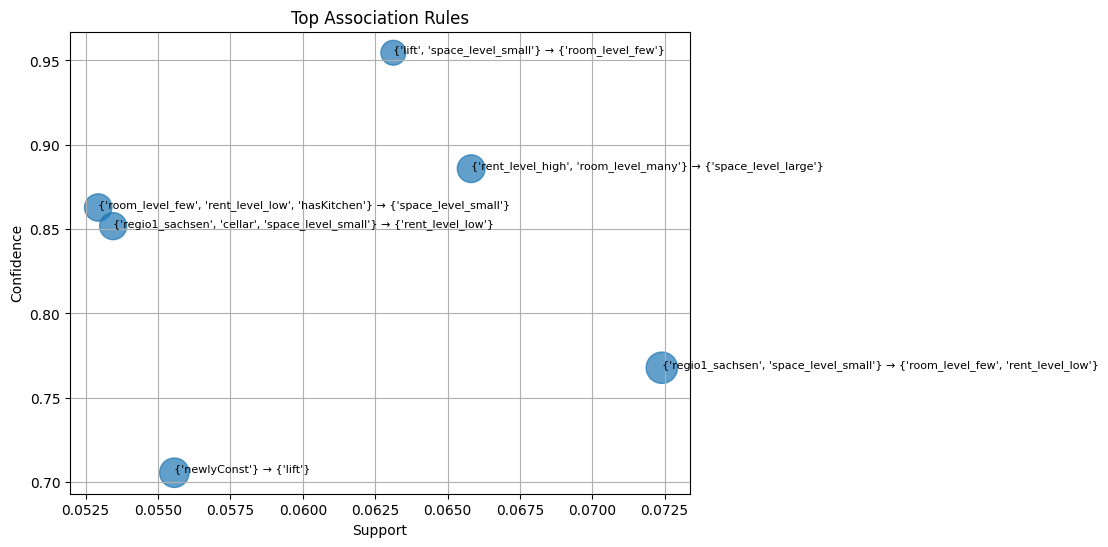

In [ ]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    top_rules['support'],
    top_rules['confidence'],
    s=top_rules['lift'] * 150, 
    alpha=0.7
)

for i, row in top_rules.iterrows():
    label = f"{set(row['antecedents'])} → {set(row['consequents'])}"
    plt.text(row['support'], row['confidence'], label, fontsize=8)

plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Top Association Rules')

plt.grid(True)
plt.show()

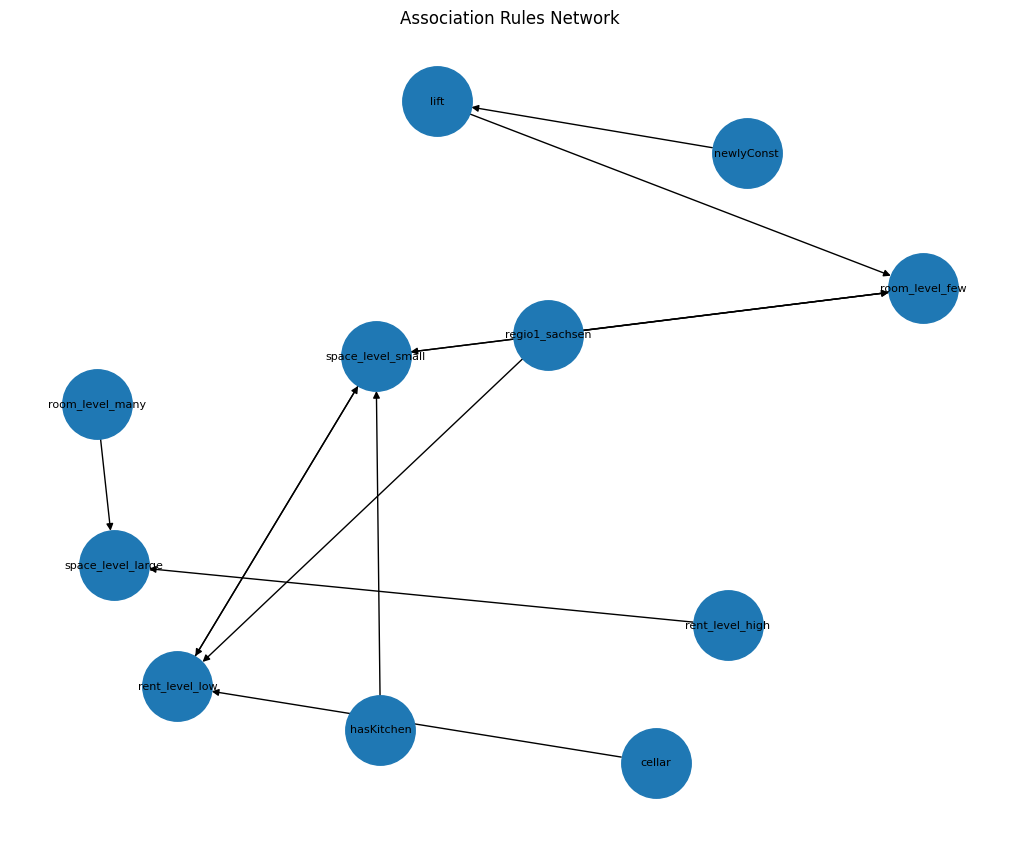

In [ ]:
import networkx as nx

G = nx.DiGraph()

for _, row in top_rules.iterrows():
    for a in row['antecedents']:
        for c in row['consequents']:
            G.add_edge(a, c)

plt.figure(figsize=(10,8))

pos = nx.spring_layout(G, k=1.5, seed=42)

nx.draw(
    G, pos,
    with_labels=True,
    node_size=2500,
    font_size=8,
    arrows=True
)

plt.title("Association Rules Network")
plt.show()

## 🌐 Association Rules Network Interpretation

The network graph visualizes the relationships between different features in the dataset, where:

- **Nodes** represent individual features (e.g., `space_level_small`, `rent_level_low`)
- **Directed edges** represent association rules (from antecedents → consequents)

---

## 🔍 Key Observations

### 1. Strong cluster around apartment size, rent, and rooms

A central cluster is formed by:
- `space_level_small`
- `rent_level_low`
- `room_level_few`
- `regio1_sachsen`

These nodes are highly connected, indicating that:

- Small apartments are strongly associated with **low rent and fewer rooms**
- Location (`regio1_sachsen`) reinforces this relationship

👉 This suggests that **size, price, and number of rooms are tightly correlated**, especially in specific regions.

---

### 2. Clear pattern for large apartments

Another visible pattern:

- `room_level_many → space_level_large`
- `rent_level_high → space_level_large`

👉 This shows that:
- Apartments with many rooms and high rent are strongly linked to larger space

This confirms a fundamental real estate relationship:
> **Higher price and more rooms imply larger apartment size**

---

### 3. Modern buildings and amenities

The connection:
- `newlyConst → lift`

👉 Indicates that:
- Newly constructed apartments are highly likely to have elevators

This reflects modern housing standards and infrastructure improvements.

---

### 4. Weak influence of certain features

Some nodes, such as:
- `cellar`
- `hasKitchen`

have fewer or weaker connections

👉 This suggests that:
- These features **do not significantly influence major outcomes** like rent or space
- They act as **secondary or less impactful attributes**

---

### 5. Combined feature effects

Some relationships only appear when features are combined:

- `space_level_small + lift → room_level_few`
- `space_level_small + regio1_sachsen → rent_level_low`

👉 This indicates that:
- Certain patterns emerge only through **interaction between features**
- Individual variables alone may not fully explain the outcome

---

## 📊 Overall Insight

The network reveals that:

- **Core structural features** (size, rent, number of rooms) dominate the dataset
- **Location** plays a significant role in determining rental characteristics
- **Modern amenities** (e.g., lift) are associated with newer buildings
- **Some features contribute only marginally** and do not strongly affect outcomes

---

## 🎯 Conclusion

The association rules network provides a clear visual summary of the dataset, highlighting both strong and weak relationships between features. It confirms expected real-world patterns while also revealing how combinations of attributes interact to influence apartment characteristics.